In [1]:
%run functions.ipynb

df_chg = pd.read_pickle('DlKKs_chgMC_df.p')
df_mix = pd.read_pickle('DlKKs_mixMC_df.p')
df_cc = pd.read_pickle('DlKKs_ccMC_df.p')
df_uds = pd.read_pickle('DlKKs_udsMC_df.p')
df_off = pd.read_pickle('DlKKs_off_df.p')
df_dat = pd.read_pickle('DlKKs_data_df.p')
df_cmc = pd.read_pickle('DlKKs_CMCX_df.p')

#---------------------------------- Data lumi = 365.290, BB cross-section = 1050000.0, Offpeak lumi = 42.740 #144643/577965 = 0.2502625591515057
df_cc2 = pd.read_pickle('old/DlKKs_ccMC_df.p')
df_chg2 = pd.read_pickle('old/DlKKs_chgMC_df.p')
df_mix2 = pd.read_pickle('old/DlKKs_mixMC_df.p')
df_dat2 = pd.read_pickle('old/DlKKs_data_df.p')
#--------------------------------- Generic MC lumi = 1461.16, wtMC = 0.250, wtMCOff = 0.029
datasmc = [df_chg,df_mix,df_cc,df_uds]
df_names = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)", r"off-resonance"]
df_namesmc = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)"]
datasmc_old = [df_chg2,df_mix2,df_cc2] #3.99 more data 
api = pdg.connect()
df_asim = df_cmc.copy() #(577965, 328) r x c initial
labbin = ['Signal','Background']
mc_weights1 = np.ndarray((577965,))
mc_weights1.fill(0.25)
mc_weights2 = np.ndarray((577965,))
mc_weights2.fill(0.002737551)
dat_weights1 = np.ndarray((144643,))
dat_weights1.fill(0.002737551)
#All header commands/imports/main variables

In [2]:
variables_to_plot = {  # dictionary defining variables to plot
    "delta_phi_ll_met": {"xlabel": r"$\Delta\phi_{\ell\ell,\mathrm{MET}}$", "bins": np.linspace(-4, 4, 30)},
    "delta_phi_ll": {"xlabel": r"$\Delta\phi_{\ell\ell}$", "bins": np.linspace(-4, 4, 40)},
    "mT": {"xlabel": r"$m_T$ [GeV]", "bins": np.linspace(0, 300, 30), "scale": 1e-3}, # 0 260, 15, 0 300, 30
    "mT_ell": {"xlabel": r"$m_T^{\ell}$ [GeV]", "bins": np.linspace(0, 300, 30)},
    "met_et": {"xlabel": r"$E_T^{\mathrm{miss}}$ [GeV]", "bins": np.linspace(0, 200, 30), "scale": 1e-3},
    "osof_mass": {"xlabel": r"$m_{\ell\ell}$ [GeV]", "bins": np.linspace(0, 200, 30), "scale": 1e-3},
    "pT_ll": {"xlabel": r"$p_T^{\ell\ell}$ [GeV]", "bins": np.linspace(0, 200, 30), "scale": 1e-3},
    "lep_pt_0": {"xlabel": r"$p_T^{\ell_1}$ [GeV]", "bins": np.linspace(0, 300, 30), "scale": 1e-3},
    "lep_pt_1": {"xlabel": r"$p_T^{\ell_2}$ [GeV]", "bins": np.linspace(0, 300, 30), "scale": 1e-3},
}
df_asim[:10]

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__eventType__,__weight__,Ecms,aBminusMode,aBplusMode,aB0Mode,aBbar0Mode,aD0Mode,aDbar0Mode,aDplusMode,aDminusMode,ECM,pCM,InvM,cosThCM,phiCM,PDG,charge,nROE_Ch,nROE_ECL,nROE_KL,Q_ROE,M_ROE,Eextra_ROE,R2,cosTBTO,nROE_ECL_loose,M_ROE_loose,Eextra_ROE_loose,mcECM,mcPCM,mcThetaCM,mcPhiCM,isSignal,mcErrors,mcPDG,genMotherID_0,genMotherPDG_0,genMotherPDG_1,genMotherPDG_2,isSignalAcceptMissing,BSL_ECM,BSL_pCM,BSL_InvM,BSL_cosThCM,BSL_phiCM,BSL_PDG,BSL_charge,BSL_BchiProb,BSL_BflightDistance,BSL_BflightDistanceErr,BSL_Bdr,BSL_Bdz,BSL_isSignal,BSL_mcErrors,BSL_mcPDG,BSL_genMotherID_0,BSL_genMotherPDG_0,BSL_genMotherPDG_1,BSL_isSignalAcceptMissing,BSL_decayModeID,BSL_cosBY,eSL_ECM,eSL_pCM,eSL_InvM,eSL_cosThCM,eSL_phiCM,eSL_PDG,eSL_charge,eSL_isSignal,eSL_mcErrors,eSL_mcPDG,eSL_genMotherID_0,eSL_genMotherPDG_0,eSL_genMotherPDG_1,eSL_isSignalAcceptMissing,eSL_electronID,eSL_muonID,D0SL_ECM,D0SL_pCM,D0SL_InvM,D0SL_cosThCM,D0SL_phiCM,D0SL_PDG,D0SL_charge,D0SL_DchiProb,D0SL_DflightDistance,D0SL_DflightDistanceErr,D0SL_Ddr,D0SL_Ddz,D0SL_mcECM,D0SL_mcPCM,D0SL_mcThetaCM,D0SL_mcPhiCM,D0SL_isSignal,D0SL_mcErrors,D0SL_mcPDG,D0SL_genMotherID_0,D0SL_genMotherPDG_0,D0SL_genMotherPDG_1,D0SL_isSignalAcceptMissing,D0SL_decayModeID,trkK0S_ECM,trkK0S_pCM,trkK0S_InvM,trkK0S_cosThCM,trkK0S_phiCM,trkK0S_PDG,trkK0S_charge,trkK0S_isSignal,trkK0S_mcErrors,trkK0S_mcPDG,trkK0S_genMotherID_0,trkK0S_genMotherPDG_0,trkK0S_genMotherPDG_1,trkK0S_isSignalAcceptMissing,trk_ECM,trk_pCM,trk_InvM,trk_cosThCM,trk_phiCM,trk_PDG,trk_charge,trk_isSignal,trk_mcErrors,trk_mcPDG,trk_genMotherID_0,trk_genMotherPDG_0,trk_genMotherPDG_1,trk_genMotherPDG_2,trk_isSignalAcceptMissing,trk_KID,trk_piID,trk_electronID_noSVD_noTOP,trk_muonID_noSVD,trk_dr,trk_d0Err,trk_dz,trk_nCDCHits,trk_nVXDHits,trk_ndf,trk_chi2,trk_lastCDCLayer,K0S_ECM,K0S_pCM,K0S_InvM,K0S_cosThCM,K0S_phiCM,K0S_PDG,K0S_charge,K0S_isSignal,K0S_mcErrors,K0S_mcPDG,K0S_genMotherID_0,K0S_genMotherPDG_0,K0S_genMotherPDG_1,K0S_genMotherPDG_2,K0S_isSignalAcceptMissing,K0S_chiProb,K0S_flightDistance,K0S_flightDistanceErr,K0S_dr,K0S_dz,pi1_ECM,pi1_pCM,pi1_InvM,pi1_cosThCM,pi1_phiCM,pi1_PDG,pi1_charge,pi1_isSignal,pi1_mcErrors,pi1_mcPDG,pi1_genMotherID_0,pi1_genMotherPDG_0,pi1_genMotherPDG_1,pi1_genMotherPDG_2,pi1_isSignalAcceptMissing,pi1_KID,pi1_piID,pi1_electronID_noSVD_noTOP,pi1_muonID_noSVD,pi1_dr,pi1_d0Err,pi1_dz,pi1_nCDCHits,pi1_nVXDHits,pi1_ndf,pi1_chi2,pi1_lastCDCLayer,pi2_ECM,pi2_pCM,pi2_InvM,pi2_cosThCM,pi2_phiCM,pi2_PDG,pi2_charge,pi2_isSignal,pi2_mcErrors,pi2_mcPDG,pi2_genMotherID_0,pi2_genMotherPDG_0,pi2_genMotherPDG_1,pi2_genMotherPDG_2,pi2_isSignalAcceptMissing,pi2_KID,pi2_piID,pi2_electronID_noSVD_noTOP,pi2_muonID_noSVD,pi2_dr,pi2_d0Err,pi2_dz,pi2_nCDCHits,pi2_nVXDHits,pi2_ndf,pi2_chi2,pi2_lastCDCLayer,nMCGen,MCGenPDG_0,MCGenMothIndex_0,MCGenPDG_1,MCGenMothIndex_1,MCGenPDG_2,MCGenMothIndex_2,MCGenPDG_3,MCGenMothIndex_3,MCGenPDG_4,MCGenMothIndex_4,MCGenPDG_5,MCGenMothIndex_5,MCGenPDG_6,MCGenMothIndex_6,MCGenPDG_7,MCGenMothIndex_7,MCGenPDG_8,MCGenMothIndex_8,MCGenPDG_9,MCGenMothIndex_9,MCGenPDG_10,MCGenMothIndex_10,MCGenPDG_11,MCGenMothIndex_11,MCGenPDG_12,MCGenMothIndex_12,MCGenPDG_13,MCGenMothIndex_13,MCGenPDG_14,MCGenMothIndex_14,MCGenPDG_15,MCGenMothIndex_15,MCGenPDG_16,MCGenMothIndex_16,MCGenPDG_17,MCGenMothIndex_17,MCGenPDG_18,MCGenMothIndex_18,MCGenPDG_19,MCGenMothIndex_19,MCGenPDG_20,MCGenMothIndex_20,MCGenPDG_21,MCGenMothIndex_21,MCGenPDG_22,MCGenMothIndex_22,MCGenPDG_23,MCGenMothIndex_23,MCGenPDG_24,MCGenMothIndex_24,MCGenPDG_25,MCGenMothIndex_25,MCGenPDG_26,MCGenMothIndex_26,MCGenPDG_27,MCGenMothIndex_27,MCGenPDG_28,MCGenMothIndex_28,MCGenPDG_29,MCGenMothIndex_29,MCGenPDG_30,MCGenMothIndex_30,MCGenPDG_31,MCGenMothIndex_31,MCGenPDG_32,MCGenMothIndex_32,MCGenPDG_33,MCGenMothIndex_33,MCGenPDG_34,MCGenMothIndex_34,MCGenPDG_35,MCGenMothIndex_35,MCGenPDG_36,MCGenMothIndex_36,MCGenPDG_37,MCGenMothIndex_37,MCGenPDG_38,MCGenMothIndex_38,

C:\Users\Thomas\AppData\Local\Temp\ipykernel_37024\999189972.py:57: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(bin_centers, sig_counts/bkg_counts, label='s/B', alpha=0.5)
C:\Users\Thomas\AppData\Local\Temp\ipykernel_37024\999189972.py:57: RuntimeWarning: invalid value encountered in divide
  ax[1].plot(bin_centers, sig_counts/bkg_counts, label='s/B', alpha=0.5)


Best symmetric mass cut:
  → Range: 0.4899 – 0.5054 GeV
  → Width: 15.50 MeV
  → S = 314540.0, B = 96791.0, FOM = 490.43


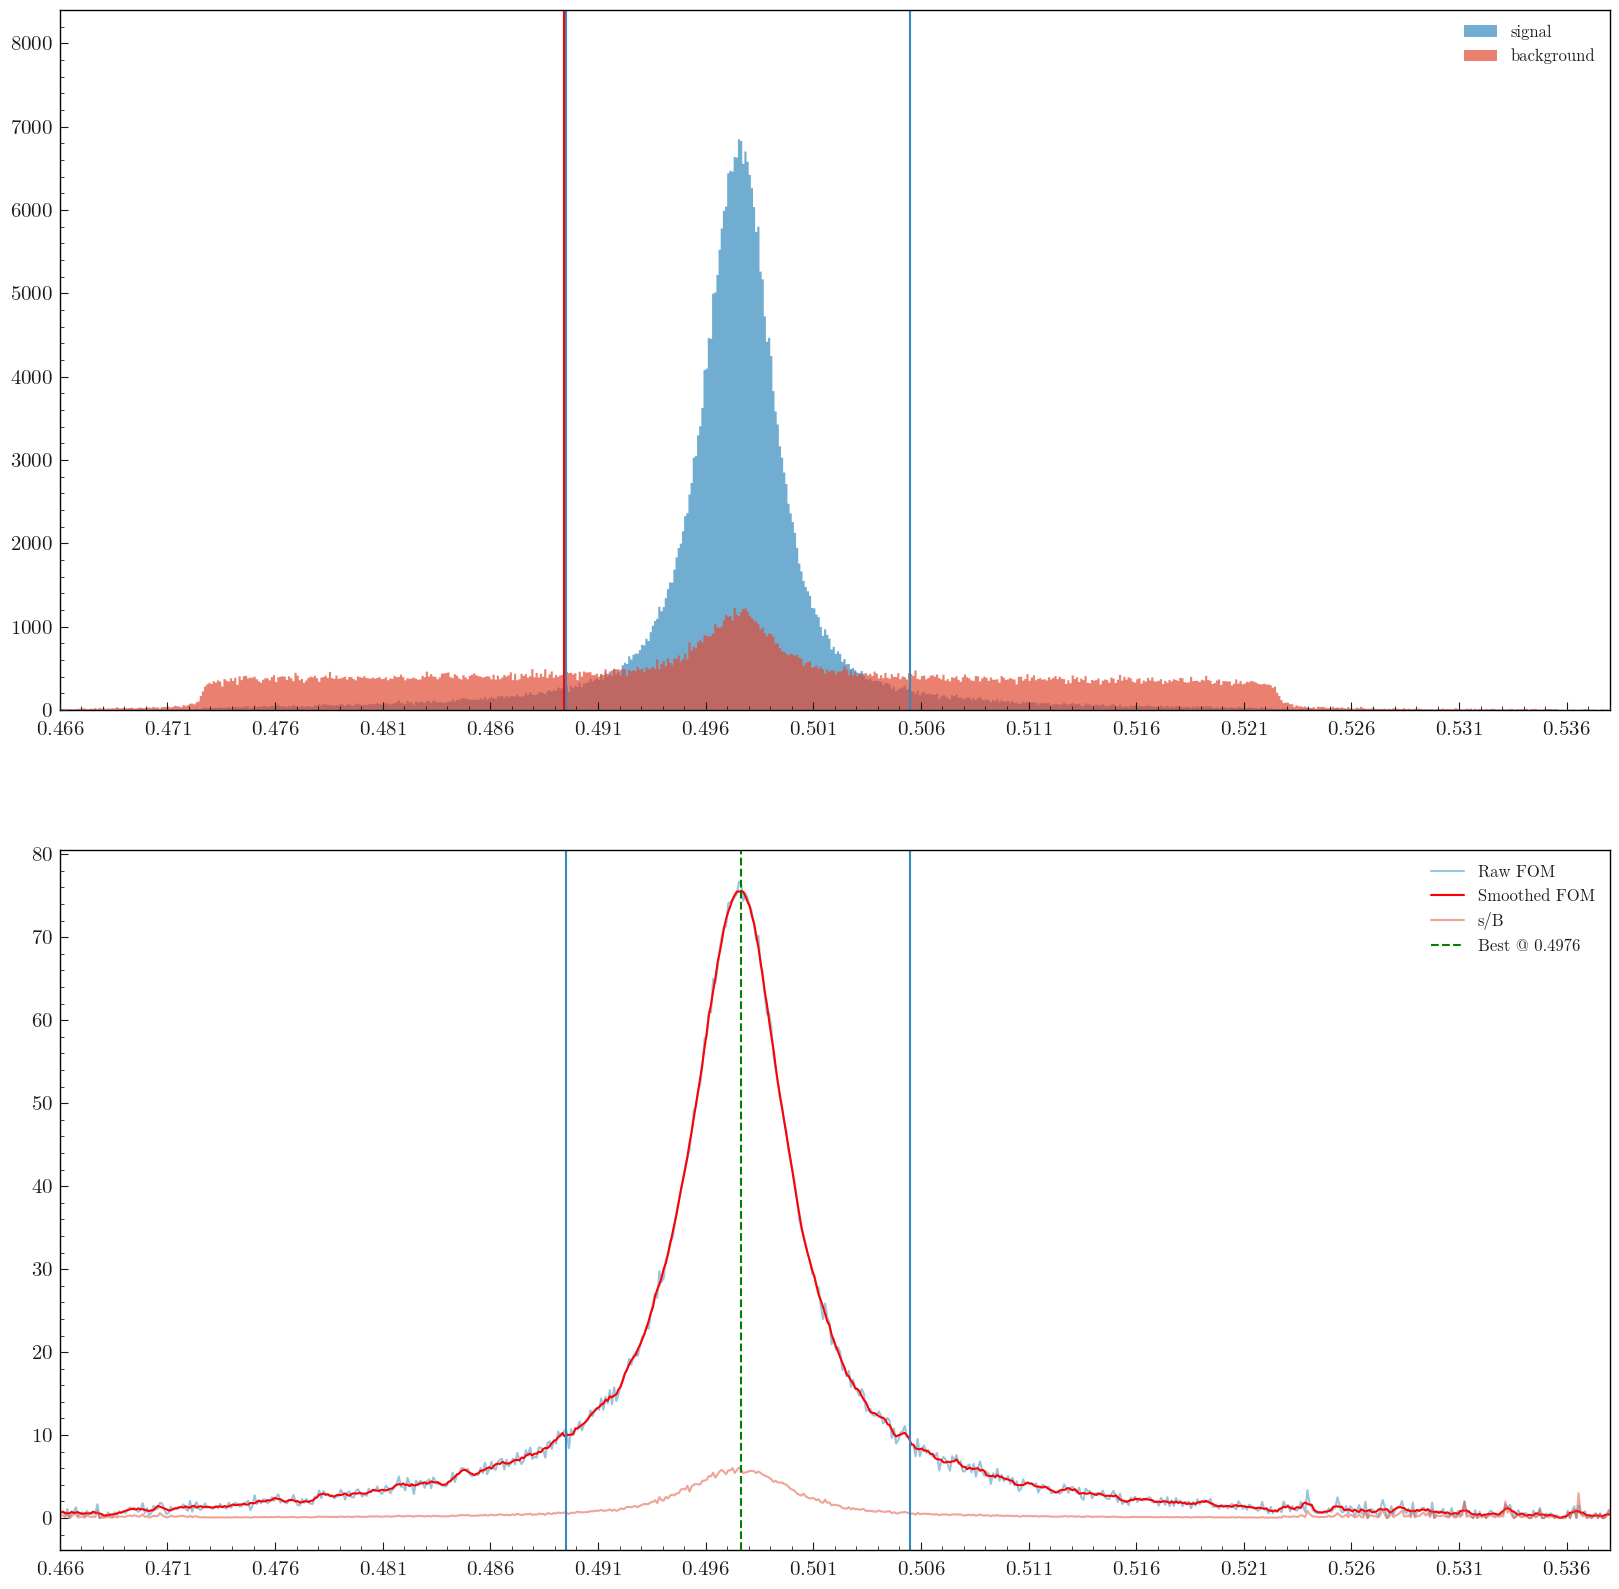

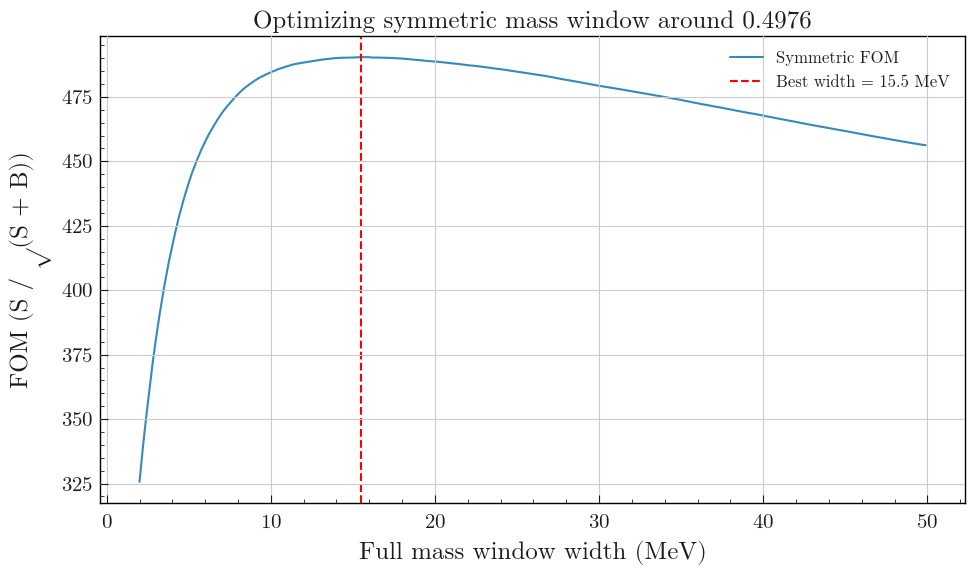

725

In [3]:
counts, binsc = np.histogram(df_asim['K0S_InvM'],np.arange(0.466, 0.5385, 0.0001))
# for i in range(len(counts2)-2, 0, -1):
#     if counts2[i] == 0 and counts2[i+1] != 0:
#         print(i) 10287 - 10996
#         break 
# 0.287 - 0.997
# 0.287+0.709
# data = df[col].dropna()  # drop NaNs just in case

# low, high = data.quantile([0.01, 0.99])
# clipped = data[(data >= low) & (data <= high)]
# 0.434-0.287 0.14700000000000002
# 0.287+0.147
# sum(counts[:])
# 230/577965*100 #0.0003979479726281003 %
# df_asim2 = df_asim['K0S_InvM'].dropna()
# low, high = df_asim2.quantile([0.05, 0.985])  # 1st and 99th percentiles


# clipped = df_asim2[(df_asim2 >= low) & (df_asim2 <= high)]
# np.sort(clipped)[:30]
fig, ax = plt.subplots(2,1,figsize=(20,20))
ax = ax.flatten()
binc0 = np.arange(0.466, 0.5385, 0.0001)
#ax[0].hist(df_asim['K0S_InvM'],bins=np.arange(0.466, 0.538, 0.001),label='total')
sig = ax[0].hist(df_asim.query('K0S_isSignal == 1 & trk_isSignal == 1')['K0S_InvM'],bins=binc0,histtype='stepfilled',label='signal',alpha=0.7)
bkg = ax[0].hist(df_asim.query('K0S_isSignal != 1 | trk_isSignal != 1')['K0S_InvM'],bins=binc0,histtype='stepfilled',label='background',alpha=0.7)
sig_counts = sig[0]
bkg_counts = bkg[0]
ax[0].legend()
ax[0].set_ylim(0,max(sig_counts + bkg_counts)*1.05)
ax[0].set_xlim(0.466,0.538)
ax[0].set_xticks(np.arange(0.466,0.538,0.005))
ax[0].axvline(0.4895)
ax[0].axvline(0.4894, color='red', linestyle='-')
ax[0].axvline(0.5055)

sig_binb = sig[1]

bin_edges = binc0
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
# Robust FOM
fom = np.divide(
    sig_counts,
    np.sqrt(sig_counts + bkg_counts),
    out=np.zeros_like(sig_counts, dtype=float),
    where=(sig_counts + bkg_counts) > 0
)

# Optional: smoothed FOM
from scipy.ndimage import uniform_filter1d
fom_smooth = uniform_filter1d(fom, size=5)

# Plot
ax[1].plot(bin_centers, fom, label='Raw FOM', alpha=0.5)
ax[1].plot(bin_centers, fom_smooth, label='Smoothed FOM', color='red')
ax[1].plot(bin_centers, sig_counts/bkg_counts, label='s/B', alpha=0.5)
# Best cut
max_idx = np.argmax(fom_smooth)
best_mass = bin_centers[max_idx]
ax[1].axvline(best_mass, color='green', linestyle='--', label=f'Best @ {best_mass:.4f}')
ax[1].legend()
ax[1].set_xticks(np.arange(0.466,0.538,0.005))
ax[1].set_xlim(0.466, 0.538)
ax[1].axvline(0.4895)
ax[1].axvline(0.5055)
import pandas as pd
import numpy as np

# --- Begin extension ---
center = best_mass  # From previous FOM peak
df = df_asim

# Create label masks
sig_mask = (df['K0S_isSignal'] == 1) & (df['trk_isSignal'] == 1)
bkg_mask = ~sig_mask

# Try symmetric windows around peak (±w)
half_widths = np.arange(0.001, 0.025, 0.00005)  # 1 MeV to 25 MeV (step = 0.5 MeV)
results = []

for w in half_widths:
    low  = center - w
    high = center + w

    window_mask = (df['K0S_InvM'] >= low) & (df['K0S_InvM'] <= high)

    S = np.count_nonzero(window_mask & sig_mask)
    B = np.count_nonzero(window_mask & bkg_mask)

    fom_window = S / np.sqrt(S + B) if (S + B) > 0 else 0
    results.append({'low': low, 'high': high, 'width': 2*w, 'S': S, 'B': B, 'FOM': fom_window})

# Turn into DataFrame
results_df = pd.DataFrame(results)

# Find the best symmetric window
best_idx = results_df['FOM'].idxmax()
best = results_df.loc[best_idx]

# Print optimal window info
print(f"Best symmetric mass cut:")
print(f"  → Range: {best['low']:.4f} – {best['high']:.4f} GeV")
print(f"  → Width: {best['width']*1000:.2f} MeV")
print(f"  → S = {best['S']}, B = {best['B']}, FOM = {best['FOM']:.2f}")

# Plot FOM vs window width
fig2, ax2 = plt.subplots(figsize=(10,6))
ax2.plot(results_df['width']*1000, results_df['FOM'], label='Symmetric FOM')
ax2.axvline(best['width']*1000, color='red', linestyle='--',
            label=f'Best width = {best["width"]*1000:.1f} MeV')
ax2.set_xlabel("Full mass window width (MeV)")
ax2.set_ylabel("FOM (S / √(S + B))")
ax2.set_title("Optimizing symmetric mass window around {:.4f}".format(center))
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()
0.48985,0.50535 
len(binc0)

In [4]:
sig_counts[315], sig_binb[315] #0.4894

(np.float64(6847.0), np.float64(0.49749999999999656))

In [5]:
(0.49759999999999655 + 0.49749999999999656)/2

0.49754999999999655

In [6]:
sig_vars = ['nROE_Ch', 'nROE_ECL', 'nROE_KL', 'Q_ROE', 'M_ROE', 'Eextra_ROE', 'R2', 'cosTBTO',
     'nROE_ECL_loose', 'M_ROE_loose', 'Eextra_ROE_loose',
     'trkK0S_ECM', 'trkK0S_pCM', 'trkK0S_InvM', 'trkK0S_cosThCM', 'trkK0S_phiCM', 'trkK0S_charge',
     'trkK0S_isSignal', 'trkK0S_isSignalAcceptMissing',
     'trk_ECM', 'trk_pCM', 'trk_InvM', 'trk_cosThCM', 'trk_phiCM', 'trk_charge',
     'trk_isSignal', 'trk_isSignalAcceptMissing', 'trk_dr', 'trk_d0Err', 'trk_dz',
     'trk_nCDCHits', 'trk_nVXDHits', 'trk_ndf', 'trk_chi2', 'trk_lastCDCLayer',
     'K0S_ECM', 'K0S_pCM', 'K0S_InvM', 'K0S_cosThCM', 'K0S_phiCM', 'K0S_charge',
     'K0S_isSignal', 'K0S_isSignalAcceptMissing', 'K0S_chiProb', 'K0S_flightDistance',
     'K0S_flightDistanceErr', 'K0S_dr', 'K0S_dz',
     'nISR', 'cosK0Strk']
tag = ['BSL_ECM', 'BSL_pCM', 'BSL_InvM', 'BSL_cosThCM', 'BSL_phiCM', 'BSL_charge',
     'BSL_BchiProb', 'BSL_BflightDistance', 'BSL_BflightDistanceErr', 'BSL_Bdr', 'BSL_Bdz',
     'BSL_isSignal', 'BSL_isSignalAcceptMissing', 'BSL_cosBY',
     'eSL_ECM', 'eSL_pCM', 'eSL_InvM', 'eSL_cosThCM', 'eSL_phiCM', 'eSL_charge',
     'eSL_isSignal', 'eSL_isSignalAcceptMissing',
     'D0SL_ECM', 'D0SL_pCM', 'D0SL_InvM', 'D0SL_cosThCM', 'D0SL_phiCM', 'D0SL_charge',
     'D0SL_DchiProb', 'D0SL_DflightDistance', 'D0SL_DflightDistanceErr',
     'D0SL_Ddr', 'D0SL_Ddz', 'D0SL_isSignal', 'D0SL_isSignalAcceptMissing',
     'cosK0SeSL', 'cosK0SD0SL']

In [7]:
df_sig2 = df_asim.query('BSL_isSignalAcceptMissing == 1.0 & trkK0S_isSignalAcceptMissing == 1.0')
df_bkg2 = df_asim.query('BSL_isSignalAcceptMissing != 1.0 | trkK0S_isSignalAcceptMissing != 1.0')

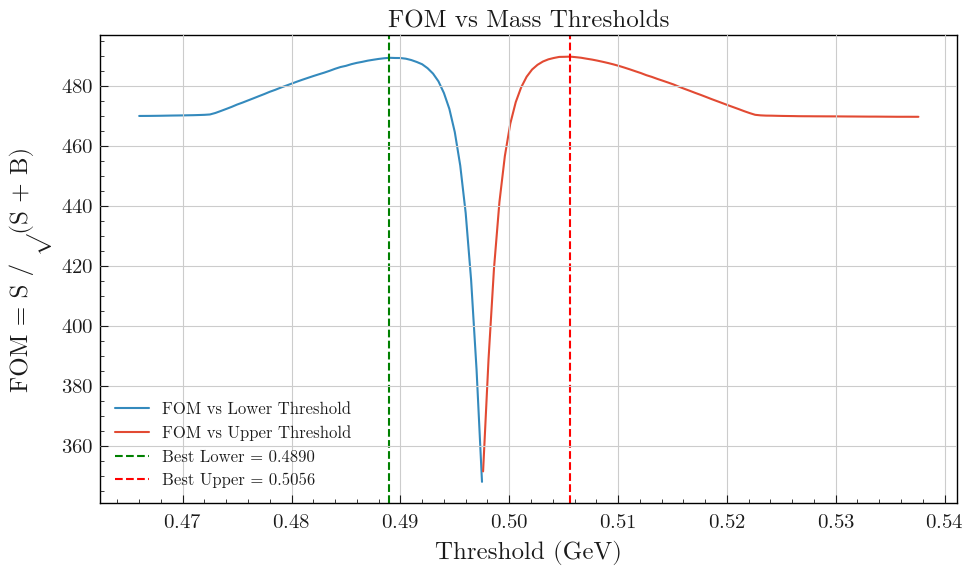

Best Lower Threshold: 0.4890 GeV (FOM = 489.31)
Best Upper Threshold: 0.5056 GeV (FOM = 489.70)


144

In [8]:
thresholds = np.arange(0.466, 0.538, 0.0005)
peak = 0.4976
sig_mask = (df['K0S_isSignal'] == 1) & (df['trk_isSignal'] == 1)
bkg_mask = ~sig_mask

# Define lower and upper threshold ranges (scan around the peak)
low_edges = np.arange(0.466, peak, 0.0005)
high_edges = np.arange(peak, 0.538, 0.0005)

fom_lows = []
fom_highs = []

# Scan over lower edge thresholds (upper edge fixed at peak + Δ)
for t_low in low_edges:
    s_tot = np.sum((df['K0S_InvM'] >= t_low) & (df['K0S_InvM'] <= peak + 0.01) & sig_mask)
    b_tot = np.sum((df['K0S_InvM'] >= t_low) & (df['K0S_InvM'] <= peak + 0.01) & bkg_mask)
    fom = s_tot / np.sqrt(s_tot + b_tot) if (s_tot + b_tot) > 0 else 0
    fom_lows.append(fom)

# Scan over upper edge thresholds (lower edge fixed at peak - Δ)
for t_high in high_edges:
    s_tot = np.sum((df['K0S_InvM'] >= peak - 0.01) & (df['K0S_InvM'] <= t_high) & sig_mask)
    b_tot = np.sum((df['K0S_InvM'] >= peak - 0.01) & (df['K0S_InvM'] <= t_high) & bkg_mask)
    fom = s_tot / np.sqrt(s_tot + b_tot) if (s_tot + b_tot) > 0 else 0
    fom_highs.append(fom)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(low_edges, fom_lows, label="FOM vs Lower Threshold")
plt.plot(high_edges, fom_highs, label="FOM vs Upper Threshold")

# Best points
best_low_idx = np.argmax(fom_lows)
best_high_idx = np.argmax(fom_highs)

best_low = low_edges[best_low_idx]
best_high = high_edges[best_high_idx]

plt.axvline(best_low, color='green', linestyle='--', label=f'Best Lower = {best_low:.4f}')
plt.axvline(best_high, color='red', linestyle='--', label=f'Best Upper = {best_high:.4f}')

plt.xlabel("Threshold (GeV)")
plt.ylabel("FOM = S / √(S + B)")
plt.title("FOM vs Mass Thresholds")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print results
print(f"Best Lower Threshold: {best_low:.4f} GeV (FOM = {fom_lows[best_low_idx]:.2f})")
print(f"Best Upper Threshold: {best_high:.4f} GeV (FOM = {fom_highs[best_high_idx]:.2f})")
len(thresholds)

In [9]:
sig = df_asim.query('K0S_isSignal == 1.0')['K0S_InvM'].to_numpy()
bkg = df_asim.query('K0S_isSignal != 1.0')['K0S_InvM'].to_numpy()


In [12]:
# get_fom_win(sig,bkg, 700) #(0.4899642906345024, 0.5051528021751974, 542.7211317403022)
# fom_thresh_low(sig,bkg,100000) #(np.float64(0.4885861863540434), np.float64(519.9644728860363))
# get_foms(sig,bkg,500)
# (np.float64(0.4887492097112468),
#  np.float64(0.5057603426368252),
#  np.float64(0.497254776174036),
#  np.float64(542.5810650236688))
# Worked pretty good for 500 bins on k0s invm. Matches eyeballing it

(np.float64(0.4887492097112468),
 np.float64(0.5057603426368252),
 np.float64(0.497254776174036),
 np.float64(542.5810650236688))

In [11]:
#fom_thresh_low(sig,bkg,100000)